## Demo notebook

In this demo we will go through the basic functionalities of `RotOptSynth`.

In [1]:
import numpy as np
from scipy.stats import unitary_group
import pennylane as qml
import time
import rotoptsynth as ros
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

/Users/david.wierichs/venvs/dev/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.4.dev4) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


In [2]:
# Pick some system size and generate a target with that size.
n = 5
N = 2**n
wires = list(range(n))
dim = 4**n
U = unitary_group.rvs(N, random_state=81512)

In [3]:
# We may first validate that the parameter-optimal QSD correctly impl
mat = qml.matrix(ros.po_qsd, wire_order=wires)(U, wires) # Compute matrix

/Users/david.wierichs/repos/rotoptsynth/rotoptsynth/linalg.py:62: RuntimeWarning: divide by zero encountered in matmul
  X = K0 @ K1.conj().T
/Users/david.wierichs/repos/rotoptsynth/rotoptsynth/linalg.py:62: RuntimeWarning: overflow encountered in matmul
  X = K0 @ K1.conj().T
/Users/david.wierichs/repos/rotoptsynth/rotoptsynth/linalg.py:62: RuntimeWarning: invalid value encountered in matmul
  X = K0 @ K1.conj().T
/Users/david.wierichs/repos/rotoptsynth/rotoptsynth/linalg.py:73: RuntimeWarning: divide by zero encountered in matmul
  M1 = (D[:, np.newaxis] * M0.conj().T) @ K1
/Users/david.wierichs/repos/rotoptsynth/rotoptsynth/linalg.py:73: RuntimeWarning: overflow encountered in matmul
  M1 = (D[:, np.newaxis] * M0.conj().T) @ K1
/Users/david.wierichs/repos/rotoptsynth/rotoptsynth/linalg.py:73: RuntimeWarning: invalid value encountered in matmul
  M1 = (D[:, np.newaxis] * M0.conj().T) @ K1
/Users/david.wierichs/venvs/dev/lib/python3.13/site-packages/autoray/autoray.py:96: RuntimeWarni

In [4]:
# Next, we look at the gate counts produced by the PO-QSD
# We will use `qml.specs` for this, which operates on `qml.QNode`.

gate_set = {"CZ", "CNOT", "RY", "RZ", "GlobalPhase"}

@qml.decompose(gate_set=gate_set)
@qml.qnode(qml.device("default.qubit", wires=n))
def node(U):
    ros.po_qsd(U, wires)
    return qml.state()

In [5]:
gates = qml.specs(node)(U)["resources"].gate_types
num_rots = sum([val for key, val in gates.items() if key in ["RX", "RY", "RZ"]])
num_cnots = sum([val for key, val in gates.items() if key in ["CNOT", "CZ", "CY"]])
exp_num_rots = 4**n - 1
exp_num_cnots = int(4**n / 2 - 3/8*(n+2)*2**n + n -1)

print(f"PO-QSD has {num_rots} rotations. We expected {exp_num_rots}.", end=" ")
if num_rots == exp_num_rots:
    print('✅')
else:
    print('❌')

print(f"PO-QSD has {num_cnots} rotations. We expected {exp_num_cnots}.", end=" ")
if num_cnots == exp_num_cnots:
    print('✅')
else:
    print('❌')
    
print(f"Finally, we expect a single GlobalPhase: {'✅' if gates.get("GlobalPhase", None) == 1 else '❌'}\n")

PO-QSD has 1023 rotations. We expected 1023. ✅
PO-QSD has 432 rotations. We expected 432. ✅
Finally, we expect a single GlobalPhase: ✅



In [6]:
# Let's also look at the CPU time:
times = []
ns = range(2, 7)
for n in tqdm(ns):
    reps = int(1000 / n**3)
    U = unitary_group.rvs(2**n, random_state=81512)
    wires = list(range(n))
    start = time.process_time()
    for _ in tqdm(range(reps)):
        ros.po_qsd(U, wires)
    times.append((time.process_time() - start)/reps)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/125 [00:00<?, ?it/s]

  0%|          | 0/37 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

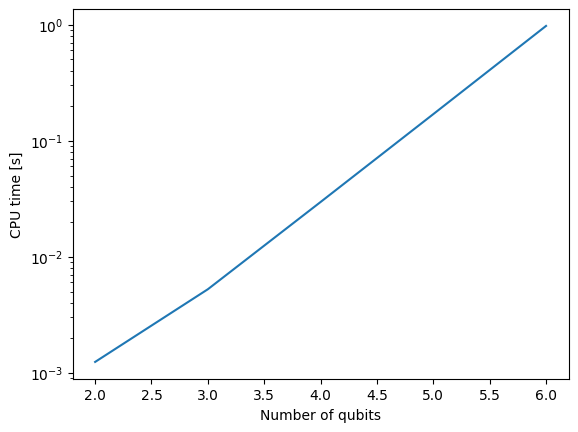

In [7]:
fig, ax = plt.subplots(1, 1)
ax.plot(ns, times)
ax.set_xlabel("Number of qubits")
ax.set_ylabel("CPU time [s]")
ax.set_yscale("log")

## README examples.

In [8]:
import numpy as np                                                                                     
from scipy.stats import unitary_group                                                                  
import pennylane as qml                                                                                
import rotoptsynth as ros                                                                              
                                                                                                       
# Pick some system size and generate a target with that size.                                          
n = 3                                                                                        
U = unitary_group.rvs(2**n, random_state=129)                                                          
wires = list(range(n))

In [9]:
implemented_matrix = qml.matrix(ros.po_qsd, wire_order=wires)(U, wires)  
np.allclose(implemented_matrix, U)

True

In [10]:
print(qml.draw(ros.po_qsd, show_matrices=False)(U, wires))

0: ──RZ(-0.75)────────────────────────────────────────────────────────────╭X──RZ(0.57)─╭X ···
1: ──RZ(0.94)───RY(1.72)─╭●──RZ(10.22)──RY(-1.99)─╭●──RZ(-1.00)──RY(1.12)─│────────────╰● ···
2: ──RZ(3.70)───RY(1.45)─╰Z──RZ(11.37)──RY(1.02)──╰Z──RZ(7.12)───RY(2.14)─╰●───────────── ···

0: ··· ──RZ(0.76)─╭X──RZ(-0.27)──RY(-0.26)─────────────────────────────────────────────────╭X ···
1: ··· ───────────│───RZ(10.04)──RY(2.20)──╭●──RZ(2.76)───RY(-2.12)─╭●──RZ(8.52)──RY(0.92)─│─ ···
2: ··· ───────────╰●──RZ(10.28)──RY(1.72)──╰Z──RZ(10.24)──RY(0.60)──╰Z──RZ(9.45)──RY(0.97)─╰● ···

0: ··· ──RY(1.54)─╭X──RY(1.07)─╭X──RY(-0.12)─╭X─────────RZ(-1.35)──────────────────────── ···
1: ··· ───────────╰●───────────│─────────────╰●─────────RZ(11.75)──RY(2.14)─╭●──RZ(13.38) ···
2: ··· ────────────────────────╰●──RZ(0.80)───RY(0.90)──────────────────────╰Z──RZ(2.14)─ ···

0: ··· ───────────────────────────────────╭X──RZ(1.28)─╭X──RZ(0.93)─╭X──RZ(2.13)─────────── ···
1: ··· ──RY(-1.84)─╭●──RZ(8.85)──RY(1.61)─│

In [11]:
n = 4
wires = list(range(n))
U = unitary_group.rvs(2**n, random_state=81512)
print(qml.draw(ros.recursive_flag_decomp, show_matrices=False)(U, wires))


0: ─╭◑─╭◑─╭◑─╭◑─╭◑─╭◑─╭◑─╭⚑─╭◑─╭◑─╭◑─╭◑─╭◑─╭◑─╭◑─╭U(M0)─┤  
1: ─├◑─├◑─├◑─├⚑─├◑─├◑─├◑─├◑─├◑─├◑─├◑─├⚑─├◑─├◑─├◑─├U(M0)─┤  
2: ─├◑─├⚑─├◑─├◑─├◑─├⚑─├◑─├◑─├◑─├⚑─├◑─├◑─├◑─├⚑─├◑─├U(M0)─┤  
3: ─╰⚑─╰◑─╰⚑─╰◑─╰⚑─╰◑─╰⚑─╰◑─╰⚑─╰◑─╰⚑─╰◑─╰⚑─╰◑─╰⚑─╰U(M0)─┤  


In [12]:
n = 3
qml.decomposition.enable_graph()

gate_set = {"RZ", "RY", "CNOT", "CZ", "GlobalPhase"}

@qml.decompose(gate_set=gate_set)
@qml.qnode(qml.device("lightning.qubit", wires=n))
def my_qnode(U):
    qml.QubitUnitary(U, wires=range(n))
    return qml.expval(qml.X(1))

U = unitary_group.rvs(2**n, random_state=81212)
my_qnode(U)

-0.1703878223917237